In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, f1_score, precision_score, recall_score

In [2]:
# ---1. Load the datasets---
ns_hra = pd.read_csv('c:\\Users\\s2421127\\Documents\\NLP Project\\ObuayaO\\NLP project\\Chapter 3\\ns_hra.csv', encoding='unicode_escape')
ns_hra['concat_corpus'] = ns_hra['Title']+ " " + ns_hra['Objective'] + " " + ns_hra['1ry_endpoint'] 
ns_hra['concat_corpus'] = ns_hra['concat_corpus'].fillna('')

euct_ns = pd.read_csv('c:\\Users\\s2421127\\Documents\\NLP Project\\ObuayaO\\NLP project\\Chapter 3\\euct_ns.csv', encoding='unicode_escape')
euct_ns['concat_corpus'] = euct_ns['Title']+ " " + euct_ns['Objective'] + " " + euct_ns['pr_endpoint'] + " " + euct_ns['endpoint_description']
euct_ns['concat_corpus'] = euct_ns['concat_corpus'].fillna('')

labelled_df= pd.read_csv('c:\\Users\\s2421127\\Documents\\NLP Project\\ObuayaO\\NLP project\\Chapter 2 Project\\label_log.csv', encoding='unicode_escape')

In [3]:
# ---2. Re-train the model on all actively labelled samples---
print("Re-training the model on all 140 actively labelled samples...")

# Prepare the training text corpus from the original ns_hra file
X_train = ns_hra['concat_corpus'].iloc[labelled_df['index']]
y_train = labelled_df['label']

# Define and train the pipeline
al_model_pipeline = make_pipeline(
    TfidfVectorizer(analyzer='word', min_df=2, ngram_range=(1, 3)),
    ComplementNB(alpha=0.1, fit_prior=True)
)
al_model_pipeline.fit(X_train, y_train)

print("Model training complete.")

Re-training the model on all 140 actively labelled samples...
Model training complete.


Applying the AL trained CNB classifier to the EUCT-NS dataset

In [4]:
# --- 3. Evaluate the new labelled dataset ---

print("\nPreparing the new labelled dataset...")

X_test = euct_ns['concat_corpus']
y_test = euct_ns['manual_label'] 

# --- 4. Make Predictions and Evaluate ---

print("Applying the AL-trained model to the new dataset and evaluating performance...")

# Use the trained model to predict labels on the new dataset
y_pred = al_model_pipeline.predict(X_test)


Preparing the new labelled dataset...
Applying the AL-trained model to the new dataset and evaluating performance...



--- Classification Report on EUCT-NS Dataset ---
              precision    recall  f1-score   support

           0       0.76      0.51      0.61       121
           1       0.23      0.58      0.33        26
           2       0.50      0.49      0.49        43

    accuracy                           0.52       190
   macro avg       0.49      0.53      0.48       190
weighted avg       0.63      0.52      0.55       190


--- Confusion Matrix ---


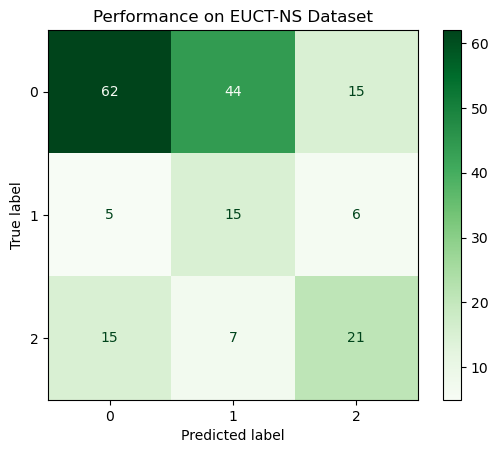

In [5]:
# --- 4a. Classification Report ---
print("\n--- Classification Report on EUCT-NS Dataset ---")
print(classification_report(y_test, y_pred, zero_division=0))

# --- 4b. Confusion Matrix ---
print("\n--- Confusion Matrix ---")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Greens)
plt.title('Performance on EUCT-NS Dataset')
plt.show()

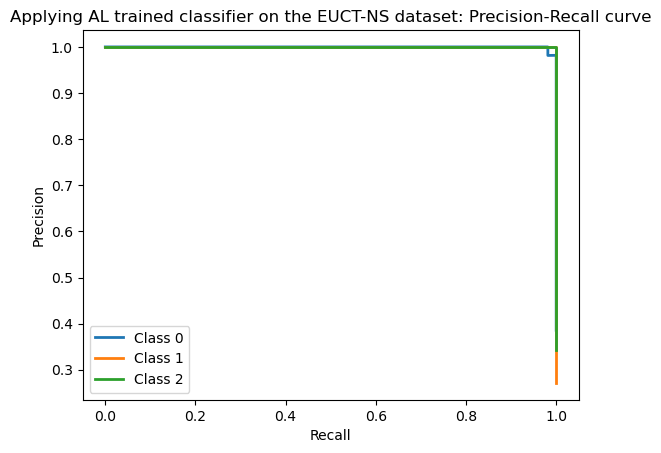

In [6]:
from sklearn.metrics import precision_recall_curve

# Compute precision-recall curve for each class
for i in range(len(al_model_pipeline.classes_)):
	y_prob_train = al_model_pipeline.predict_proba(X_train)[:, i]
	y_prob_test = al_model_pipeline.predict_proba(X_test)[:, i]

	precision, recall, thresholds = precision_recall_curve(y_train == i, y_prob_train)
	plt.plot(recall, precision, lw=2, label=f'Class {i}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Applying AL trained classifier on the EUCT-NS dataset: Precision-Recall curve")
plt.legend(loc="best")
plt.show()

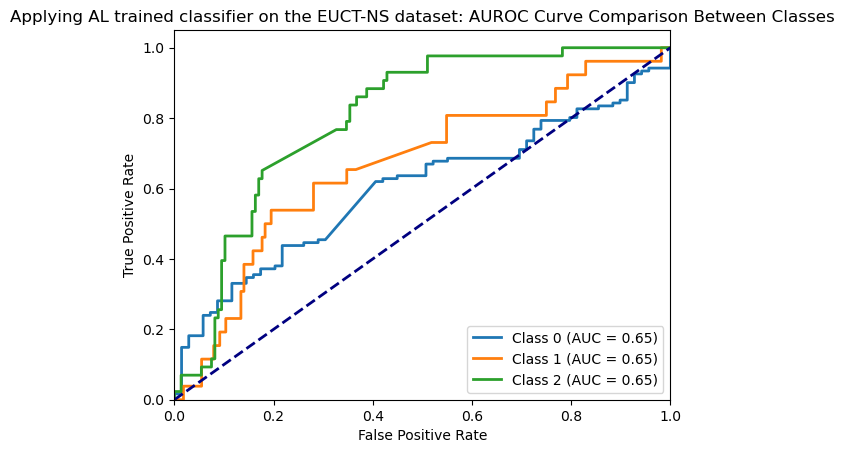

In [9]:
# --- 4d. AUROC ---
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=al_model_pipeline.classes_)
y_prob = al_model_pipeline.predict_proba(X_test)

# Calculate the AUC - ROC score
roc_auc = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')

# Compute ROC curve for each class
for i in range(al_model_pipeline.classes_.shape[0]):
	fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
	plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Applying AL trained classifier on the EUCT-NS dataset: AUROC Curve Comparison Between Classes')
plt.legend(loc="lower right")
plt.show()

Compare AL to SL

In [12]:
import numpy as np
from mlxtend.evaluate import mcnemar_table, mcnemar
from sklearn.model_selection import train_test_split

In [13]:
X = euct_ns['concat_corpus']
y = euct_ns['manual_label']

In [14]:
# Using the same random_state as the AL training set ensures the test set is identical for a fair comparison.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# --- Train the Classic Supervised Model ---
print("Training the classic supervised model...")
supervised_model_pipeline = make_pipeline(
    TfidfVectorizer(analyzer='word', min_df=2, ngram_range=(1, 3)),
    ComplementNB(alpha=0.1, fit_prior=True)
)
supervised_model_pipeline.fit(X_train, y_train)


# --- Get the Predictions ---
y_pred_supervised = supervised_model_pipeline.predict(X_test)

print("Supervised model predictions are ready.")

Training the classic supervised model...
Supervised model predictions are ready.


In [15]:
y_true = y_test
y_pred_al_model = al_model_pipeline.predict(X_test)
y_pred_supervised_model = np.array(y_pred_supervised)


# --- Build the Contingency Table ---
tb = mcnemar_table(y_target=y_true, 
                   y_model1=y_pred_al_model, 
                   y_model2=y_pred_supervised_model)

print("McNemar's Contingency Table:")
print(tb)


# --- Perform the Chi-Squared Test ---
# The exact=False argument uses a chi-squared correction, which is standard.
chi2, p_value = mcnemar(ary=tb, exact=False)

print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

McNemar's Contingency Table:
[[19  4]
 [20 14]]

Chi-squared statistic: 9.38
P-value: 0.0022
